In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report
from sklearn.model_selection import cross_val_score

In [78]:
df=pd.read_csv("titanic_data.csv")
print(df.head(5))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch     Fare  
0      0   7.2500  
1      0  71.2833  
2      0   7.9250  
3      0  53.1000  
4      0   8.0500  


In [79]:
df["TotalFamily"]=df["SibSp"]+df["Parch"]+1
print(df.head(5))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch     Fare  TotalFamily  
0      0   7.2500            2  
1      0  71.2833            2  
2      0   7.9250            1  
3      0  53.1000            2  
4      0   8.0500            1  


In [81]:
df.fillna(df["Age"].median(),inplace=True)

In [82]:
df["AgeGroup"]=pd.cut(
    df["Age"],
    bins=[0,12,18,50,80],
    labels=["Child","Teen","Adult","Senior"]
)

In [83]:
print(df.head(5))
print(df.isnull().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch     Fare  TotalFamily AgeGroup  
0      0   7.2500            2    Adult  
1      0  71.2833            2    Adult  
2      0   7.9250            1    Adult  
3      0  53.1000            2    Adult  
4      0   8.0500            1    Adult  
PassengerId    0
Survived       0
Pclass         0
Name           0


In [84]:
le=LabelEncoder()
df["Sex"]=le.fit_transform(df["Sex"])
df["AgeGroup"]=le.fit_transform(df["AgeGroup"])

In [126]:
df["Title"] = df["Name"].str.extract(r' ([A-Za-z]+)\.', expand=False)

rare_titles = ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"]
df["Title"] = df["Title"].replace(rare_titles, "Rare")
df["Title"] = df["Title"].replace({"Mlle":"Miss","Ms":"Miss","Mme":"Mrs"})
df["Title"]=le.fit_transform(df["Title"])


In [127]:
st=StandardScaler()
df[["Age","Fare"]]=st.fit_transform(df[["Age","Fare"]])

In [128]:
print(df.head(5
              ))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex       Age  SibSp  \
0                            Braund, Mr. Owen Harris    1 -0.565736      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  0.663861      1   
2                             Heikkinen, Miss. Laina    0 -0.258337      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  0.433312      1   
4                           Allen, Mr. William Henry    1  0.433312      0   

   Parch      Fare  TotalFamily  AgeGroup  Title Titles  
0      0 -0.502445            2         0      2     Mr  
1      0  0.786845            2         0      3    Mrs  
2      0 -0.488854            1         0      1   Miss  
3      0  0.420730            2         0      3    Mrs  
4      0 -0.486337      

In [129]:
X=df[["Pclass","Sex","Fare","TotalFamily","AgeGroup","Title"]]
y=df["Survived"]

In [130]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [131]:
print(X_train.shape)
print(X_train.shape)
print(y_train.shape)
print(y_test.shape)
print(df.head(5))

(712, 6)
(712, 6)
(712,)
(179,)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex       Age  SibSp  \
0                            Braund, Mr. Owen Harris    1 -0.565736      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  0.663861      1   
2                             Heikkinen, Miss. Laina    0 -0.258337      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  0.433312      1   
4                           Allen, Mr. William Henry    1  0.433312      0   

   Parch      Fare  TotalFamily  AgeGroup  Title Titles  
0      0 -0.502445            2         0      2     Mr  
1      0  0.786845            2         0      3    Mrs  
2      0 -0.488854            1         0      1   Miss  
3      0  0.420730            2         0      3  

In [136]:
model=RandomForestClassifier(n_estimators=400,
    max_depth=12,
    min_samples_leaf=2,class_weight="balanced",
    
    random_state=42)
cv_scores=cross_val_score(model,X,y,cv=5,scoring="accuracy")
model.fit(X_train,y_train)
prediction=model.predict(X_test)


In [137]:
print("Accuracy Score=",accuracy_score(y_test,prediction))
print("Classification Report",classification_report(y_test,prediction))

Accuracy Score= 0.8435754189944135
Classification Report               precision    recall  f1-score   support

           0       0.88      0.85      0.86       105
           1       0.79      0.84      0.82        74

    accuracy                           0.84       179
   macro avg       0.84      0.84      0.84       179
weighted avg       0.85      0.84      0.84       179



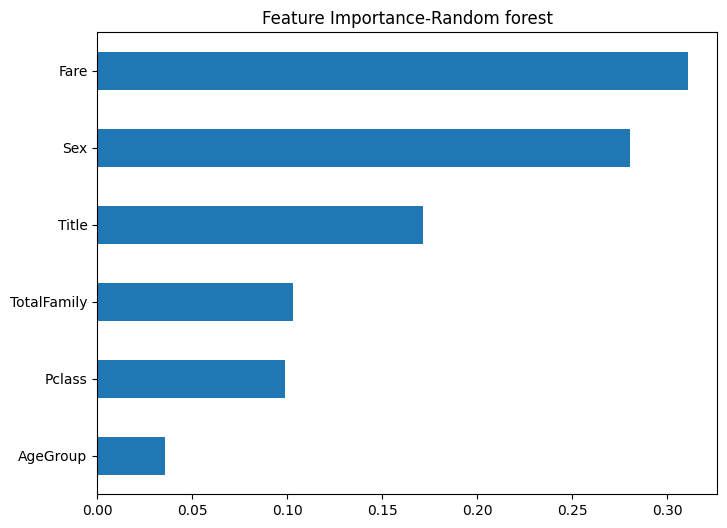

<Figure size 640x480 with 0 Axes>

In [138]:
importance=pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)
importance.plot(kind="barh",figsize=(8,6))
plt.title("Feature Importance-Random forest")
plt.show()
plt.savefig("Feature Importance.png",dpi=300)